# 🛰️ **Model Comparison — U-Net vs DeepLabV3+**

> **Prerequisites:** Run `water_segmentation_unet.ipynb` and `water_segmentation_deeplab.ipynb` first.
> Both checkpoints must exist:
> - `/kaggle/working/best_unet.keras`
> - `/kaggle/working/best_deeplab.pth`

**What this notebook covers:**
1. Setup & Data Loading (same test split as training notebooks)
2. Load Both Models
3. Model Size & Architecture Comparison
4. Inference Speed Comparison
5. Metrics Comparison (IoU, F1, Precision, Recall)
6. Threshold Sensitivity Comparison
7. Side-by-Side Visual Predictions
8. Error Analysis
9. Final Verdict Table

## **1. Setup & Data Loading**

In [1]:
!pip install rasterio segmentation-models-pytorch -qU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.6 MB/s eta 0:00:0000:01


In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
import tensorflow.keras.backend as K

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
print('TF     :', tf.__version__)
print('PyTorch:', torch.__version__)

2026-04-26 09:19:11.187703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777195151.653408      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777195151.789170      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777195152.824710      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777195152.824752      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777195152.824755      55 computation_placer.cc:177] computation placer alr

Device : cuda
TF     : 2.19.0
PyTorch: 2.10.0+cu128


In [3]:
# ── Paths ──
IMAGES_PATH = "/kaggle/input/datasets/mahmoudosamahassan/satellite-dataset/satalite data/data/images"
LABELS_PATH = "/kaggle/input/datasets/mahmoudosamahassan/satellite-dataset/satalite data/data/labels"

UNET_PATH   = '/kaggle/input/models/mahmoudosamahassan/best-unet-v2/keras/default/1/best_unet.keras'
DEEPLAB_PATH= '/kaggle/input/models/mahmoudosamahassan/best-deeplab-v2/pytorch/default/1/best_deeplab.pth'

BAND_NAMES = [
    'Coastal Aerosol', 'Blue', 'Green', 'Red', 'NIR',
    'SWIR1', 'SWIR2', 'QA Band',
    'Merit DEM', 'Copernicus DEM',
    'ESA World Cover', 'Water Occurrence Prob'
]
N_BANDS = 12

In [4]:
# ── Load raw data (same logic as both training notebooks) ──
all_image_files = sorted(os.listdir(IMAGES_PATH))
all_label_files = sorted(os.listdir(LABELS_PATH))

image_stems  = {os.path.splitext(f)[0]: f for f in all_image_files}
label_stems  = {os.path.splitext(f)[0]: f for f in all_label_files}
matched_stems = sorted(set(image_stems) & set(label_stems))

image_files = [image_stems[s] for s in matched_stems]
label_files = [label_stems[s] for s in matched_stems]
print(f'Matched pairs: {len(matched_stems)}')

X_raw = np.zeros((len(image_files), 128, 128, N_BANDS), dtype=np.float32)
Y_raw = np.zeros((len(label_files), 128, 128, 1),       dtype=np.float32)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i, (img_f, lbl_f) in enumerate(zip(image_files, label_files)):
        with rasterio.open(os.path.join(IMAGES_PATH, img_f)) as src:
            X_raw[i] = np.transpose(src.read().astype(np.float32), (1, 2, 0))
        lbl = np.array(Image.open(os.path.join(LABELS_PATH, lbl_f)))
        Y_raw[i, :, :, 0] = (lbl > 0).astype(np.float32)

print(f'X_raw: {X_raw.shape} | Y_raw: {Y_raw.shape}')

Matched pairs: 306
X_raw: (306, 128, 128, 12) | Y_raw: (306, 128, 128, 1)


In [5]:
# ── Preprocessing (must match exactly what training notebooks used) ──
def preprocess(X_raw, fit_stats=None):
    X = X_raw.copy().astype(np.float32)

    # 1. Reflectance bands 0-6: clip + standardize
    REFL_BANDS = list(range(7))
    for b in REFL_BANDS:
        X[..., b] = np.clip(X[..., b], 0.0, 10000.0)
    if fit_stats is None:
        refl_mean = np.array([X[..., b].mean() for b in REFL_BANDS], dtype=np.float32)
        refl_std  = np.array([X[..., b].std() + 1e-8 for b in REFL_BANDS], dtype=np.float32)
    else:
        refl_mean, refl_std = fit_stats['refl_mean'], fit_stats['refl_std']
    for i, b in enumerate(REFL_BANDS):
        X[..., b] = (X[..., b] - refl_mean[i]) / refl_std[i]

    # 2. QA band (7) → binary bad-pixel flag
    qa_int = X_raw[..., 7].astype(np.int32)
    bad    = np.clip(((qa_int>>3)&1) + ((qa_int>>4)&1) + ((qa_int>>5)&1), 0, 1)
    X[..., 7] = bad.astype(np.float32)

    # 3. DEM (8-9) → fill NoData + min-max
    if fit_stats is None:
        dem_fill, dem_min, dem_max = {}, {}, {}
    for b in [8, 9]:
        nd = X[..., b] < -9000
        if fit_stats is None:
            valid    = X[..., b][~nd]
            fill_val = float(np.median(valid)) if valid.size > 0 else 0.0
            bmin, bmax = float(valid.min()), float(valid.max())
            dem_fill[b], dem_min[b], dem_max[b] = fill_val, bmin, bmax
        else:
            fill_val = fit_stats['dem_fill'][b]
            bmin, bmax = fit_stats['dem_min'][b], fit_stats['dem_max'][b]
        X[..., b][nd] = fill_val
        X[..., b] = np.clip((X[..., b] - bmin) / (bmax - bmin + 1e-8), 0, 1)

    # 4. ESA World Cover (10) → binary water flag
    X[..., 10] = (X_raw[..., 10].astype(int) == 80).astype(np.float32)

    # 5. Water occurrence probability (11) → [0,1]
    X[..., 11] = np.clip(X_raw[..., 11] / 100.0, 0, 1)

    # 6. Engineered indices
    g  = np.clip(X_raw[..., 2], 0, 10000).astype(np.float32)
    n  = np.clip(X_raw[..., 4], 0, 10000).astype(np.float32)
    s1 = np.clip(X_raw[..., 5], 0, 10000).astype(np.float32)
    s2 = np.clip(X_raw[..., 6], 0, 10000).astype(np.float32)

    ndwi  = np.clip((g - n)  / (g + n  + 1e-8), -1, 1)
    mndwi = np.clip((g - s1) / (g + s1 + 1e-8), -1, 1)
    awei  = 4*(g - s1) - (0.25*n + 2.75*s2)

    if fit_stats is None:
        awei_mean = float(awei.mean())
        awei_std  = float(awei.std() + 1e-8)
    else:
        awei_mean, awei_std = fit_stats['awei_mean'], fit_stats['awei_std']
    awei_norm = (awei - awei_mean) / awei_std

    # Stack: 14 channels for U-Net, 15 channels for DeepLab (with AWEI)
    X_14 = np.concatenate([X, ndwi[...,np.newaxis], mndwi[...,np.newaxis]], axis=-1)
    X_15 = np.concatenate([X, ndwi[...,np.newaxis], mndwi[...,np.newaxis], awei_norm[...,np.newaxis]], axis=-1)

    if fit_stats is None:
        fit_stats = {
            'refl_mean': refl_mean, 'refl_std': refl_std,
            'dem_fill': dem_fill, 'dem_min': dem_min, 'dem_max': dem_max,
            'awei_mean': awei_mean, 'awei_std': awei_std
        }

    return X_14, X_15, fit_stats


# ── Same split as training (SEED=42 guarantees identical test set) ──
X_tr_raw, X_tmp_raw, Y_train, Y_tmp = train_test_split(
    X_raw, Y_raw, test_size=0.2, random_state=SEED)
X_val_raw, X_te_raw, Y_val, Y_test = train_test_split(
    X_tmp_raw, Y_tmp, test_size=0.5, random_state=SEED)

# Fit stats on train, apply to test
_, _, fit_stats = preprocess(X_tr_raw, fit_stats=None)
X_test_14, X_test_15, _ = preprocess(X_te_raw, fit_stats=fit_stats)

print(f'Test samples : {len(Y_test)}')
print(f'X_test_14    : {X_test_14.shape}  (U-Net input)')
print(f'X_test_15    : {X_test_15.shape}  (DeepLab input)')

Test samples : 31
X_test_14    : (31, 128, 128, 14)  (U-Net input)
X_test_15    : (31, 128, 128, 15)  (DeepLab input)


## **2. Load Both Models**

In [6]:
# ── U-Net custom objects ──
POS_WEIGHT = float((Y_train.size - Y_train.sum()) / (Y_train.sum() + 1e-8))

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2.*intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def weighted_bce(y_true, y_pred, pos_weight=POS_WEIGHT):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weight_map = tf.squeeze(y_true, axis=-1)*pos_weight + (1-tf.squeeze(y_true, axis=-1))
    return K.mean(weight_map * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def precision_metric(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin)
    fp = tf.reduce_sum((1-y_true) * y_pred_bin)
    return (tp + 1e-6) / (tp + fp + 1e-6)

def recall_metric(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin)
    fn = tf.reduce_sum(y_true * (1-y_pred_bin))
    return (tp + 1e-6) / (tp + fn + 1e-6)

def f1_metric(y_true, y_pred):
    p = precision_metric(y_true, y_pred)
    r = recall_metric(y_true, y_pred)
    return 2*p*r / (p + r + 1e-6)

# ── Load U-Net ──
unet = tf.keras.models.load_model(
    UNET_PATH,
    custom_objects={
        'combined_loss'   : combined_loss,
        'iou_metric'      : iou_metric,
        'precision_metric': precision_metric,
        'recall_metric'   : recall_metric,
        'f1_metric'       : f1_metric,
    }
)
print('U-Net loaded ✓')

I0000 00:00:1777195216.063257      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777195216.069311      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


U-Net loaded ✓


In [7]:
# ── Load DeepLabV3+ ──
deeplab = smp.DeepLabV3Plus(
    encoder_name    = 'efficientnet-b3',
    encoder_weights = None,     # no pretrained — we load our checkpoint
    in_channels     = 15,
    classes         = 1,
    activation      = None
).to(DEVICE)

ckpt = torch.load(DEEPLAB_PATH, map_location=DEVICE, weights_only=False)
deeplab.load_state_dict(ckpt['model_state_dict'])
deeplab.eval()
print(f'DeepLabV3+ loaded ✓  (from epoch {ckpt["epoch"]}, val IoU={ckpt["val_iou"]:.4f})')

DeepLabV3+ loaded ✓  (from epoch 17, val IoU=0.7369)


## **3. Model Size & Architecture Comparison**

ARCHITECTURE COMPARISON
                                      U-Net                  DeepLabV3+
Metric                                                                 
Architecture           U-Net (from scratch)                  DeepLabV3+
Framework                  TensorFlow/Keras               PyTorch / SMP
Backbone              None (custom encoder)  EfficientNet-B3 (ImageNet)
Input Channels                           14                          15
Total Parameters                  7,772,097                  11,684,505
Trainable Parameters              7,772,097                  11,684,505
Model File Size (MB)                93.5 MB                    136.4 MB


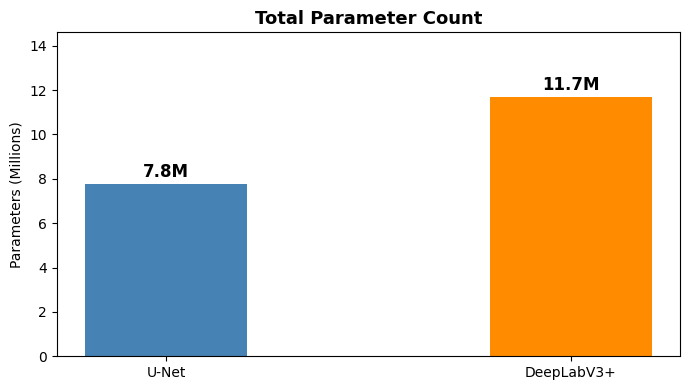

In [8]:
# ── Parameter counts ──
unet_params    = unet.count_params()
deeplab_total  = sum(p.numel() for p in deeplab.parameters())
deeplab_train  = sum(p.numel() for p in deeplab.parameters() if p.requires_grad)

# Model file sizes on disk
unet_mb    = os.path.getsize(UNET_PATH)    / 1e6
deeplab_mb = os.path.getsize(DEEPLAB_PATH) / 1e6

arch_df = pd.DataFrame({
    'Metric': [
        'Architecture', 'Framework', 'Backbone',
        'Input Channels', 'Total Parameters', 'Trainable Parameters',
        'Model File Size (MB)'
    ],
    'U-Net': [
        'U-Net (from scratch)', 'TensorFlow/Keras', 'None (custom encoder)',
        14, f'{unet_params:,}', f'{unet_params:,}',
        f'{unet_mb:.1f} MB'
    ],
    'DeepLabV3+': [
        'DeepLabV3+', 'PyTorch / SMP', 'EfficientNet-B3 (ImageNet)',
        15, f'{deeplab_total:,}', f'{deeplab_train:,}',
        f'{deeplab_mb:.1f} MB'
    ]
}).set_index('Metric')

print('=' * 60)
print('ARCHITECTURE COMPARISON')
print('=' * 60)
print(arch_df.to_string())

# Bar chart: parameter count
fig, ax = plt.subplots(figsize=(7, 4))
models  = ['U-Net', 'DeepLabV3+']
params  = [unet_params / 1e6, deeplab_total / 1e6]
colors  = ['steelblue', 'darkorange']
bars = ax.bar(models, params, color=colors, width=0.4)
for bar, val in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}M', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Total Parameter Count', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(params) * 1.25)
plt.tight_layout()
plt.show()

## **4. Inference Speed Comparison**

I0000 00:00:1777195225.037295     141 service.cc:152] XLA service 0x7fac2c059ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777195225.037334     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777195225.037338     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777195225.451542     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777195229.780225     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



INFERENCE SPEED (batch=8, averaged over 20 runs)
                     U-Net DeepLabV3+
Metric                               
Batch inference (ms)  98.8      108.8
Per-image (ms)        12.3       13.6
Images/second           81         74


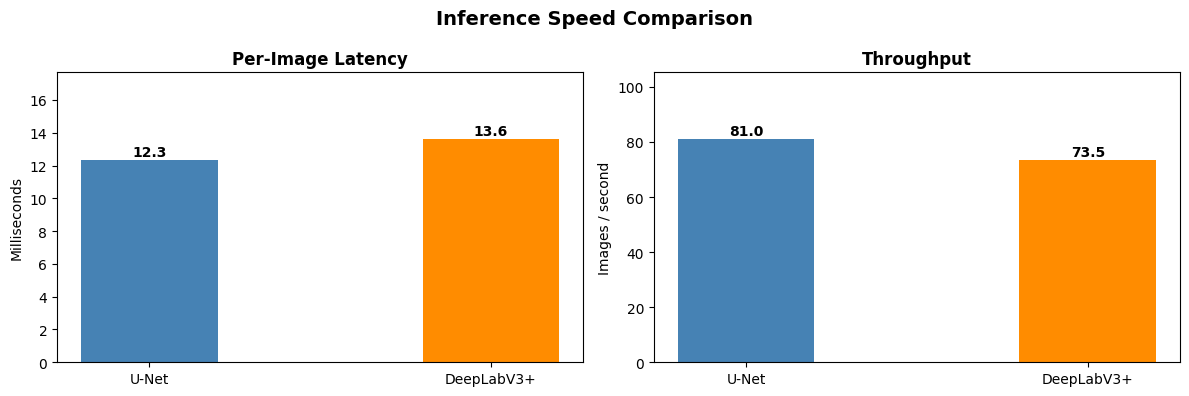

In [9]:
N_WARMUP = 3
N_RUNS   = 20
BATCH    = X_test_14[:8]   # single batch of 8 samples

# ── U-Net speed (TensorFlow) ──
for _ in range(N_WARMUP):
    _ = unet.predict(BATCH, verbose=0)

unet_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    unet.predict(BATCH, verbose=0)
    unet_times.append((time.perf_counter() - t0) * 1000)  # ms

unet_batch_ms  = np.mean(unet_times)
unet_img_ms    = unet_batch_ms / 8

# ── DeepLabV3+ speed (PyTorch) ──
batch_torch = torch.tensor(X_test_15[:8]).permute(0,3,1,2).float().to(DEVICE)

with torch.no_grad():
    for _ in range(N_WARMUP):
        _ = deeplab(batch_torch)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

deeplab_times = []
with torch.no_grad():
    for _ in range(N_RUNS):
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = deeplab(batch_torch)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        deeplab_times.append((time.perf_counter() - t0) * 1000)

deeplab_batch_ms = np.mean(deeplab_times)
deeplab_img_ms   = deeplab_batch_ms / 8

speed_df = pd.DataFrame({
    'Metric'               : ['Batch inference (ms)', 'Per-image (ms)', 'Images/second'],
    'U-Net'                : [f'{unet_batch_ms:.1f}',    f'{unet_img_ms:.1f}',    f'{1000/unet_img_ms:.0f}'],
    'DeepLabV3+'           : [f'{deeplab_batch_ms:.1f}', f'{deeplab_img_ms:.1f}', f'{1000/deeplab_img_ms:.0f}']
}).set_index('Metric')

print('\nINFERENCE SPEED (batch=8, averaged over 20 runs)')
print(speed_df.to_string())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, title, ylabel in zip(
        axes,
        [[unet_img_ms, deeplab_img_ms], [1000/unet_img_ms, 1000/deeplab_img_ms]],
        ['Per-Image Latency', 'Throughput'],
        ['Milliseconds', 'Images / second']):
    bars = ax.bar(['U-Net', 'DeepLabV3+'], vals, color=['steelblue', 'darkorange'], width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:.1f}', ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals)*1.3)

plt.suptitle('Inference Speed Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **5. Metrics Comparison on Test Set**

In [10]:
# ── Run inference on full test set ──
print('Running U-Net inference...')
unet_probs = unet.predict(X_test_14, batch_size=16, verbose=0)   # (N,128,128,1)

print('Running DeepLabV3+ inference...')
deeplab_probs_list = []
with torch.no_grad():
    for i in range(0, len(X_test_15), 8):
        batch = torch.tensor(X_test_15[i:i+8]).permute(0,3,1,2).float().to(DEVICE)
        out   = torch.sigmoid(deeplab(batch)).cpu().numpy()  # (B,1,H,W)
        deeplab_probs_list.append(out)
deeplab_probs = np.concatenate(deeplab_probs_list, axis=0)  # (N,1,H,W)
# Reformat to (N,H,W,1) to match U-Net
deeplab_probs = deeplab_probs.transpose(0, 2, 3, 1)

print(f'U-Net probs shape   : {unet_probs.shape}')
print(f'DeepLab probs shape : {deeplab_probs.shape}')

Running U-Net inference...
Running DeepLabV3+ inference...
U-Net probs shape   : (31, 128, 128, 1)
DeepLab probs shape : (31, 128, 128, 1)


In [11]:
def compute_all_metrics(probs, y_true, threshold=0.5):
    """Returns dict of metrics given probability array and ground truth."""
    preds      = (probs > threshold).astype(int)
    y_true_int = y_true.astype(int)

    pf = preds.flatten()
    tf = y_true_int.flatten()

    tp = ((pf==1) & (tf==1)).sum()
    fp = ((pf==1) & (tf==0)).sum()
    fn = ((pf==0) & (tf==1)).sum()
    tn = ((pf==0) & (tf==0)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2*precision*recall / (precision+recall+1e-8)
    iou       = tp / (tp+fp+fn+1e-8)
    accuracy  = (tp+tn) / (tp+fp+fn+tn+1e-8)

    return {
        'IoU'      : round(iou,       4),
        'F1'       : round(f1,        4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall,    4),
        'Accuracy' : round(accuracy,  4),
    }


unet_metrics    = compute_all_metrics(unet_probs,    Y_test)
deeplab_metrics = compute_all_metrics(deeplab_probs, Y_test)

metrics_df = pd.DataFrame({
    'U-Net'     : unet_metrics,
    'DeepLabV3+': deeplab_metrics
})
metrics_df['Winner'] = metrics_df.apply(
    lambda row: '🏆 DeepLabV3+' if row['DeepLabV3+'] > row['U-Net'] else '🏆 U-Net', axis=1
)

print('\n' + '='*50)
print('TEST SET METRICS COMPARISON (threshold=0.5)')
print('='*50)
print(metrics_df.to_string())


TEST SET METRICS COMPARISON (threshold=0.5)
            U-Net  DeepLabV3+        Winner
IoU        0.7790      0.7126       🏆 U-Net
F1         0.8757      0.8322       🏆 U-Net
Precision  0.8824      0.7590       🏆 U-Net
Recall     0.8692      0.9211  🏆 DeepLabV3+
Accuracy   0.9498      0.9244       🏆 U-Net


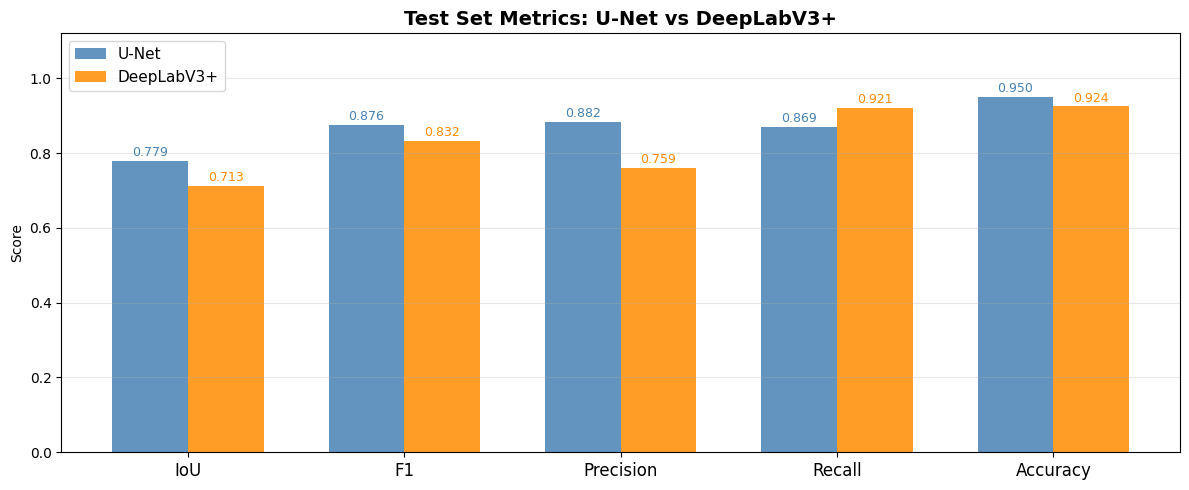

In [12]:
# ── Grouped bar chart ──
metric_names = list(unet_metrics.keys())
unet_vals    = [unet_metrics[m]    for m in metric_names]
deeplab_vals = [deeplab_metrics[m] for m in metric_names]

x   = np.arange(len(metric_names))
w   = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, unet_vals,    w, label='U-Net',      color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, deeplab_vals, w, label='DeepLabV3+', color='darkorange', alpha=0.85)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='steelblue')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Test Set Metrics: U-Net vs DeepLabV3+', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## **6. Threshold Sensitivity Comparison**

U-Net best threshold    : 0.45  →  F1=0.8765, IoU=0.7801
DeepLabV3+ best threshold: 0.80  →  F1=0.8519, IoU=0.7421


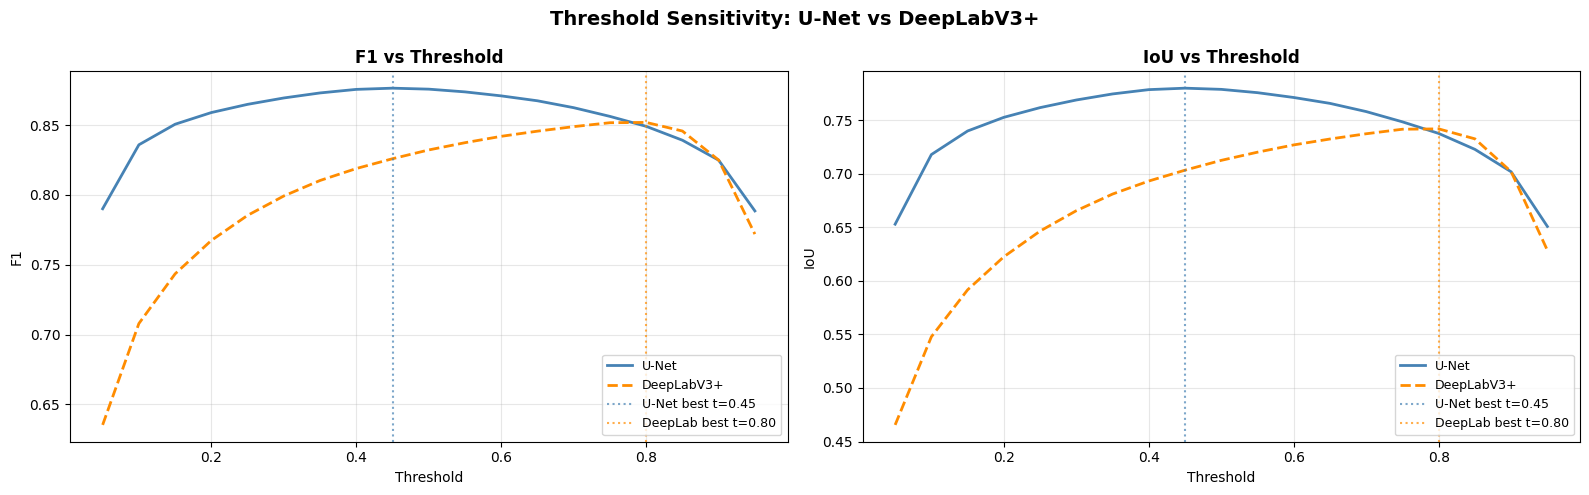

In [13]:
thresholds  = np.arange(0.05, 0.96, 0.05)
y_true_flat = Y_test.flatten().astype(int)

def threshold_sweep(probs, y_true_flat, thresholds):
    rows = []
    pf = probs.flatten()
    for t in thresholds:
        pred = (pf > t).astype(int)
        tp = ((pred==1)&(y_true_flat==1)).sum()
        fp = ((pred==1)&(y_true_flat==0)).sum()
        fn = ((pred==0)&(y_true_flat==1)).sum()
        prec = tp/(tp+fp+1e-8); rec = tp/(tp+fn+1e-8)
        f1   = 2*prec*rec/(prec+rec+1e-8)
        iou  = tp/(tp+fp+fn+1e-8)
        rows.append({'Threshold': t, 'Precision': prec, 'Recall': rec, 'F1': f1, 'IoU': iou})
    return pd.DataFrame(rows)

unet_thresh_df    = threshold_sweep(unet_probs,    y_true_flat, thresholds)
deeplab_thresh_df = threshold_sweep(deeplab_probs, y_true_flat, thresholds)

unet_best    = unet_thresh_df.loc[unet_thresh_df['F1'].idxmax()]
deeplab_best = deeplab_thresh_df.loc[deeplab_thresh_df['F1'].idxmax()]

print(f'U-Net best threshold    : {unet_best["Threshold"]:.2f}  →  F1={unet_best["F1"]:.4f}, IoU={unet_best["IoU"]:.4f}')
print(f'DeepLabV3+ best threshold: {deeplab_best["Threshold"]:.2f}  →  F1={deeplab_best["F1"]:.4f}, IoU={deeplab_best["IoU"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for metric, ax in zip(['F1', 'IoU'], axes):
    ax.plot(unet_thresh_df['Threshold'],    unet_thresh_df[metric],
            label='U-Net', color='steelblue', linewidth=2)
    ax.plot(deeplab_thresh_df['Threshold'], deeplab_thresh_df[metric],
            label='DeepLabV3+', color='darkorange', linewidth=2, linestyle='--')
    ax.axvline(unet_best['Threshold'],    color='steelblue',  linestyle=':', alpha=0.7,
               label=f'U-Net best t={unet_best["Threshold"]:.2f}')
    ax.axvline(deeplab_best['Threshold'], color='darkorange', linestyle=':', alpha=0.7,
               label=f'DeepLab best t={deeplab_best["Threshold"]:.2f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Threshold', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Threshold Sensitivity: U-Net vs DeepLabV3+', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **7. Side-by-Side Visual Predictions**

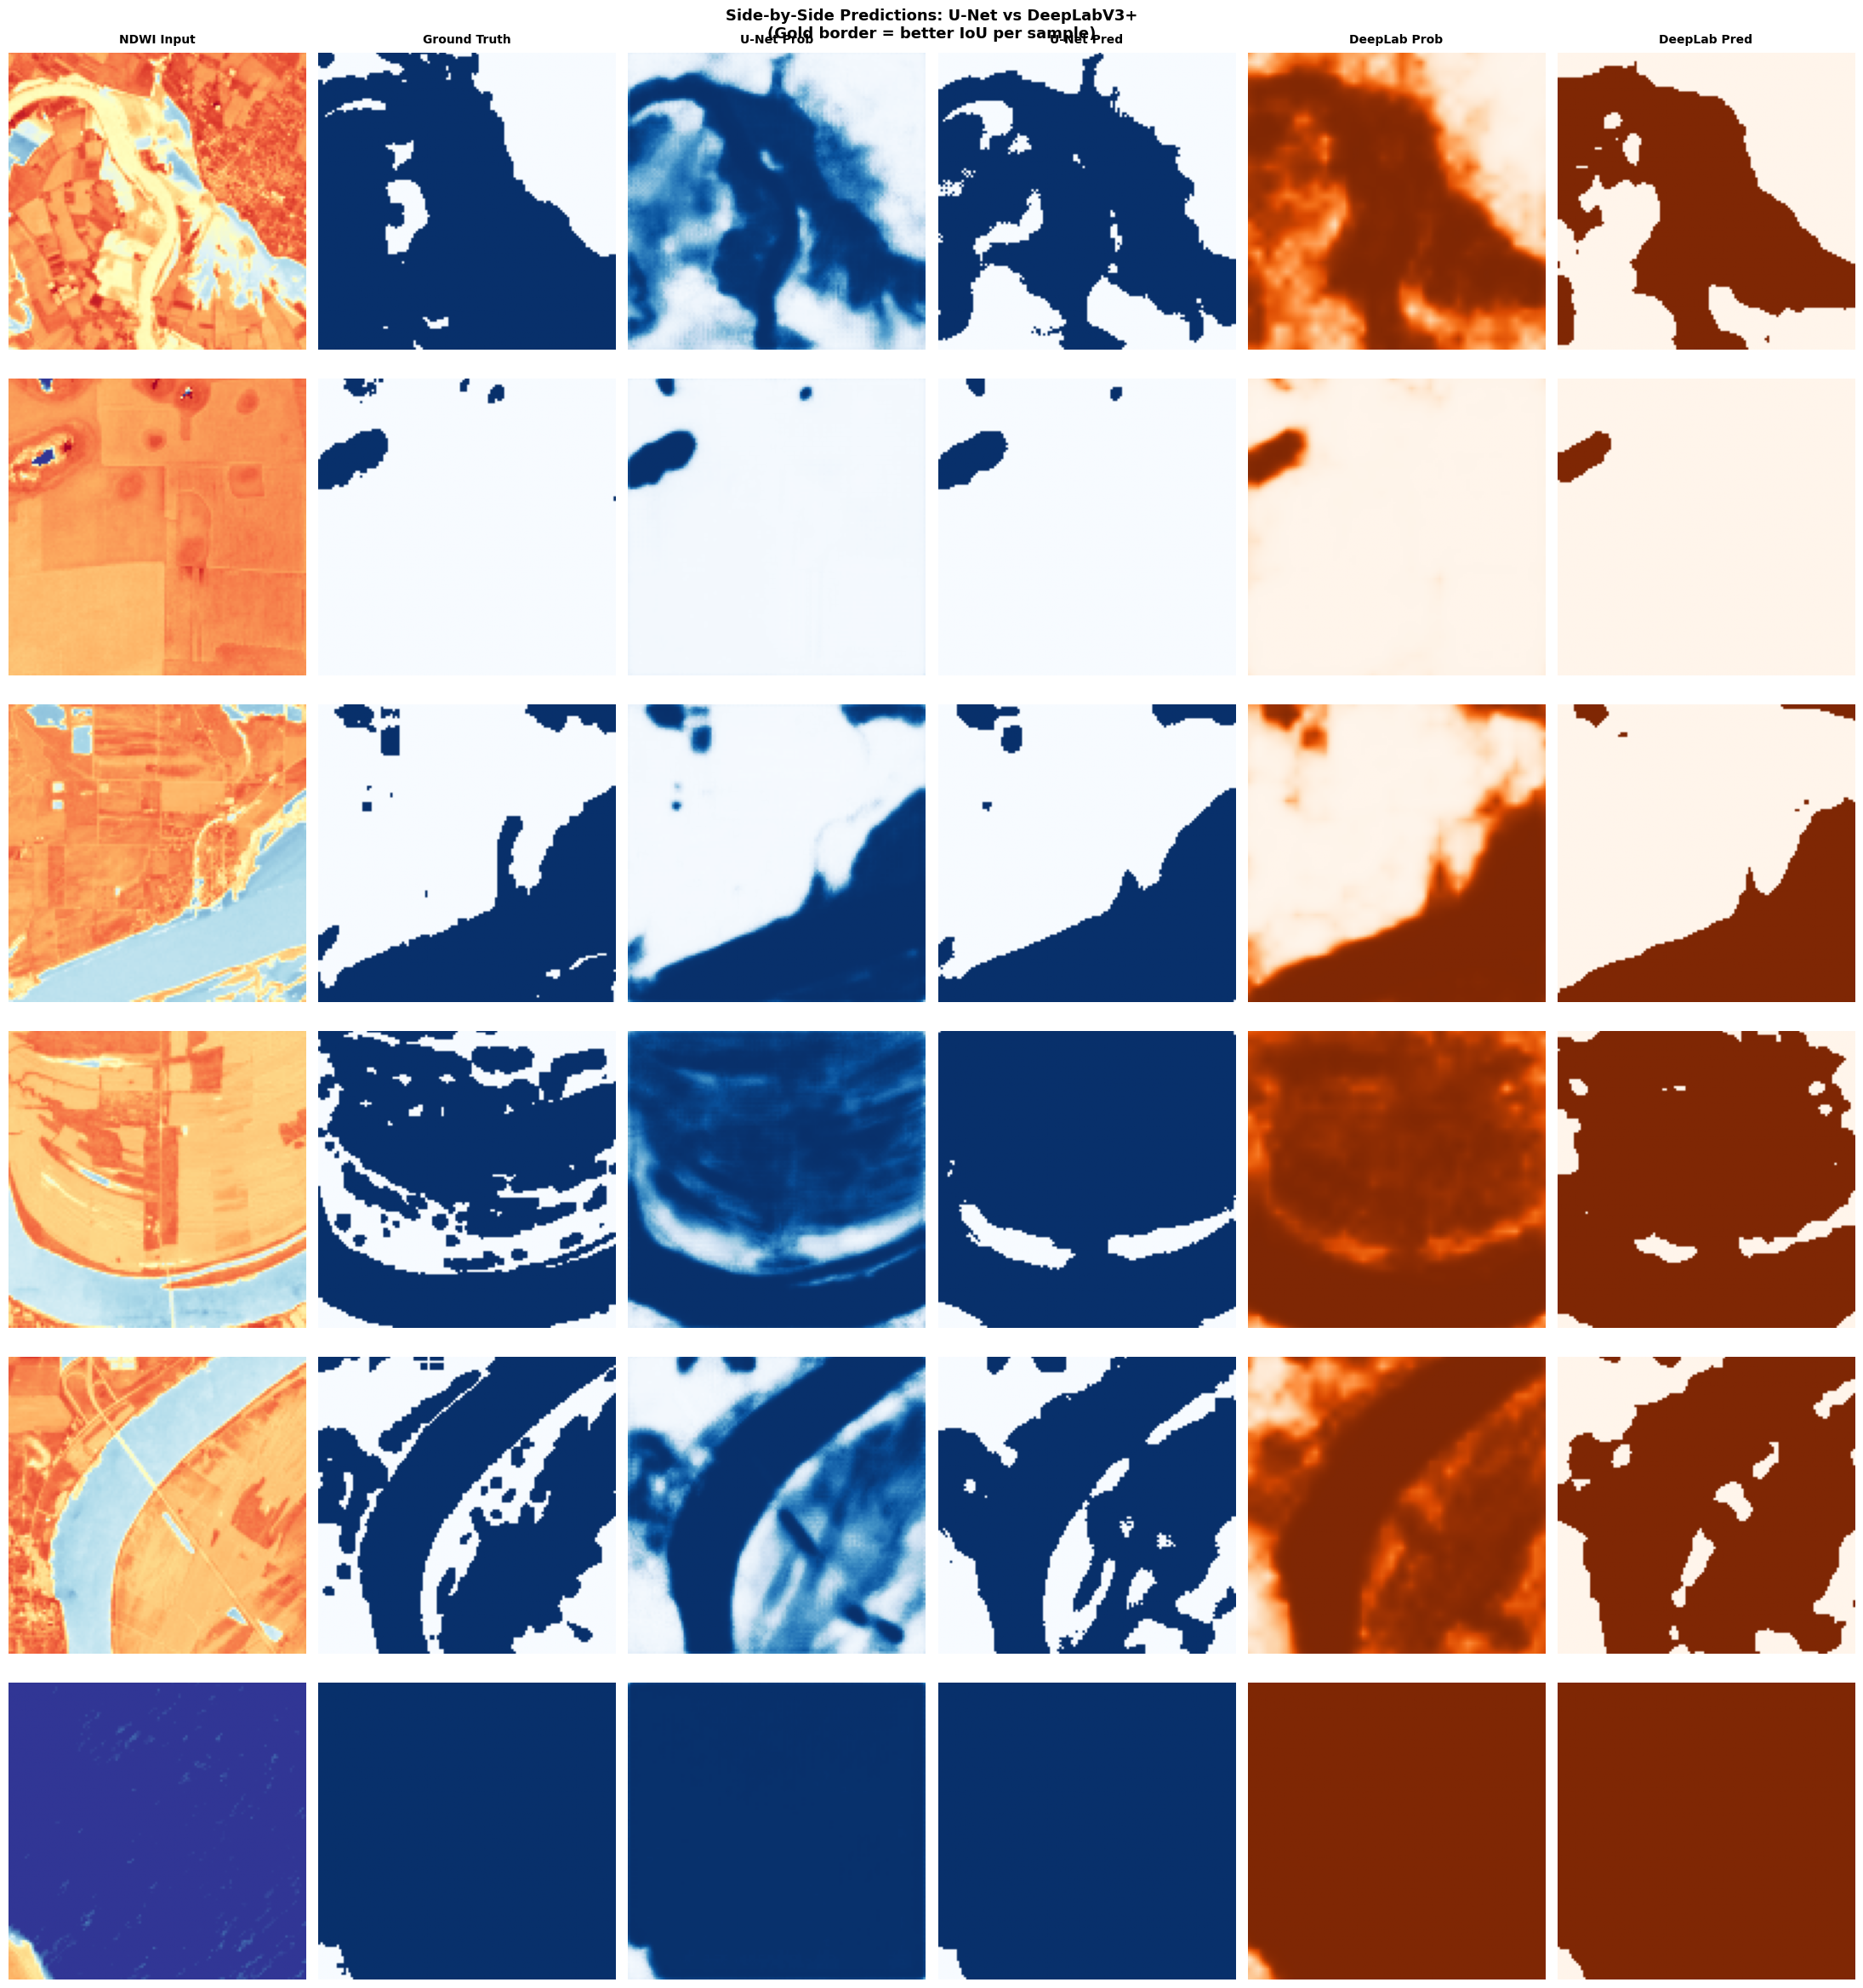

In [14]:
UNET_THRESH   = float(unet_best['Threshold'])
DEEPLAB_THRESH= float(deeplab_best['Threshold'])

def side_by_side(X_test_14, Y_test, unet_probs, deeplab_probs,
                 unet_t=UNET_THRESH, deeplab_t=DEEPLAB_THRESH, n=5):
    """
    For each sample shows 6 columns:
    NDWI | Ground Truth | U-Net Prob | U-Net Pred | DeepLab Prob | DeepLab Pred
    """
    indices = np.random.choice(len(X_test_14), n, replace=False)
    fig, axes = plt.subplots(n, 6, figsize=(22, n*4))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['NDWI Input', 'Ground Truth',
                  'U-Net Prob', 'U-Net Pred',
                  'DeepLab Prob', 'DeepLab Pred']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=8)

    for row, idx in enumerate(indices):
        ndwi_ch  = X_test_14[idx, :, :, 12]
        gt       = Y_test[idx, :, :, 0]
        u_prob   = unet_probs[idx, :, :, 0]
        d_prob   = deeplab_probs[idx, :, :, 0]
        u_pred   = (u_prob > unet_t).astype(float)
        d_pred   = (d_prob > deeplab_t).astype(float)

        def sample_iou(pred, gt):
            inter = (pred*gt).sum(); union = pred.sum()+gt.sum()-inter
            return inter/(union+1e-8)

        u_iou = sample_iou(u_pred, gt)
        d_iou = sample_iou(d_pred, gt)

        axes[row, 0].imshow(ndwi_ch, cmap='RdYlBu', vmin=-1, vmax=1)
        axes[row, 0].set_ylabel(f'Sample #{idx}\nWater: {gt.mean():.1%}', fontsize=8)

        axes[row, 1].imshow(gt, cmap='Blues', vmin=0, vmax=1)

        axes[row, 2].imshow(u_prob, cmap='Blues', vmin=0, vmax=1)
        axes[row, 2].set_xlabel(f'IoU={u_iou:.3f}', fontsize=8, color='steelblue')

        axes[row, 3].imshow(u_pred, cmap='Blues', vmin=0, vmax=1)
        axes[row, 3].set_xlabel(f't={unet_t:.2f}', fontsize=8, color='steelblue')

        axes[row, 4].imshow(d_prob, cmap='Oranges', vmin=0, vmax=1)
        axes[row, 4].set_xlabel(f'IoU={d_iou:.3f}', fontsize=8, color='darkorange')

        axes[row, 5].imshow(d_pred, cmap='Oranges', vmin=0, vmax=1)
        axes[row, 5].set_xlabel(f't={deeplab_t:.2f}', fontsize=8, color='darkorange')

        # Winner annotation
        winner = 'U-Net' if u_iou > d_iou else 'DeepLab'
        col_idx = 3 if winner == 'U-Net' else 5
        axes[row, col_idx].patch.set_edgecolor('gold')
        axes[row, col_idx].patch.set_linewidth(3)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Side-by-Side Predictions: U-Net vs DeepLabV3+\n(Gold border = better IoU per sample)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

side_by_side(X_test_14, Y_test, unet_probs, deeplab_probs, n=6)

## **8. Error Analysis**

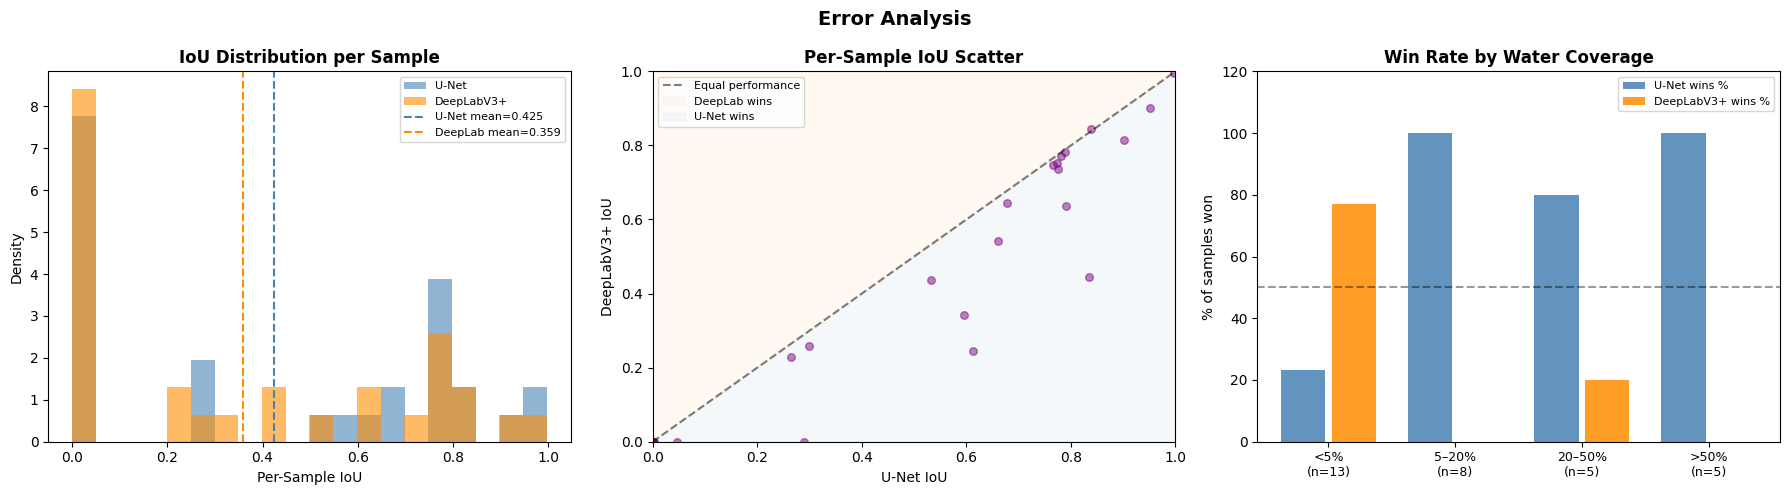

DeepLabV3+ beats U-Net on 3.2% of test samples
U-Net beats DeepLabV3+ on 96.8% of test samples


In [15]:
# ── Per-sample IoU distribution ──
def per_sample_iou(probs, y_true, threshold=0.5):
    ious = []
    for i in range(len(probs)):
        pred = (probs[i,...,0] > threshold).astype(float)
        gt   = y_true[i,...,0]
        inter = (pred*gt).sum(); union = pred.sum()+gt.sum()-inter
        ious.append(inter/(union+1e-8))
    return np.array(ious)

unet_ious    = per_sample_iou(unet_probs,    Y_test, UNET_THRESH)
deeplab_ious = per_sample_iou(deeplab_probs, Y_test, DEEPLAB_THRESH)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(unet_ious,    bins=20, alpha=0.6, label='U-Net',      color='steelblue',  density=True)
axes[0].hist(deeplab_ious, bins=20, alpha=0.6, label='DeepLabV3+', color='darkorange', density=True)
axes[0].axvline(unet_ious.mean(),    color='steelblue',  linestyle='--', label=f'U-Net mean={unet_ious.mean():.3f}')
axes[0].axvline(deeplab_ious.mean(), color='darkorange', linestyle='--', label=f'DeepLab mean={deeplab_ious.mean():.3f}')
axes[0].set_xlabel('Per-Sample IoU'); axes[0].set_ylabel('Density')
axes[0].set_title('IoU Distribution per Sample', fontweight='bold')
axes[0].legend(fontsize=8)

# Scatter: U-Net IoU vs DeepLab IoU per sample
axes[1].scatter(unet_ious, deeplab_ious, alpha=0.5, color='purple', s=30)
lims = [0, 1]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='Equal performance')
axes[1].fill_between(lims, lims, [1,1], alpha=0.05, color='darkorange', label='DeepLab wins')
axes[1].fill_between(lims, [0,0], lims, alpha=0.05, color='steelblue',  label='U-Net wins')
axes[1].set_xlabel('U-Net IoU'); axes[1].set_ylabel('DeepLabV3+ IoU')
axes[1].set_title('Per-Sample IoU Scatter', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

# Win rate by water coverage bucket
buckets  = [(0,0.05,'<5%'), (0.05,0.2,'5–20%'), (0.2,0.5,'20–50%'), (0.5,1.01,'>50%')]
water_cov= Y_test.squeeze().reshape(len(Y_test),-1).mean(axis=1)
unet_wins, deeplab_wins, bucket_labels = [], [], []
for lo, hi, label in buckets:
    mask = (water_cov >= lo) & (water_cov < hi)
    if mask.sum() == 0:
        continue
    u_win = (unet_ious[mask] > deeplab_ious[mask]).mean()
    d_win = 1 - u_win
    unet_wins.append(u_win*100)
    deeplab_wins.append(d_win*100)
    bucket_labels.append(f'{label}\n(n={mask.sum()})')

x_b = np.arange(len(bucket_labels))
axes[2].bar(x_b - 0.2, unet_wins,    0.35, label='U-Net wins %',      color='steelblue',  alpha=0.85)
axes[2].bar(x_b + 0.2, deeplab_wins, 0.35, label='DeepLabV3+ wins %', color='darkorange', alpha=0.85)
axes[2].set_xticks(x_b); axes[2].set_xticklabels(bucket_labels, fontsize=9)
axes[2].set_ylabel('% of samples won')
axes[2].set_ylim(0, 120)
axes[2].set_title('Win Rate by Water Coverage', fontweight='bold')
axes[2].axhline(50, color='black', linestyle='--', alpha=0.4)
axes[2].legend(fontsize=8)

plt.suptitle('Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

deeplab_wins_total = (deeplab_ious > unet_ious).mean()
print(f'DeepLabV3+ beats U-Net on {deeplab_wins_total:.1%} of test samples')
print(f'U-Net beats DeepLabV3+ on {1-deeplab_wins_total:.1%} of test samples')

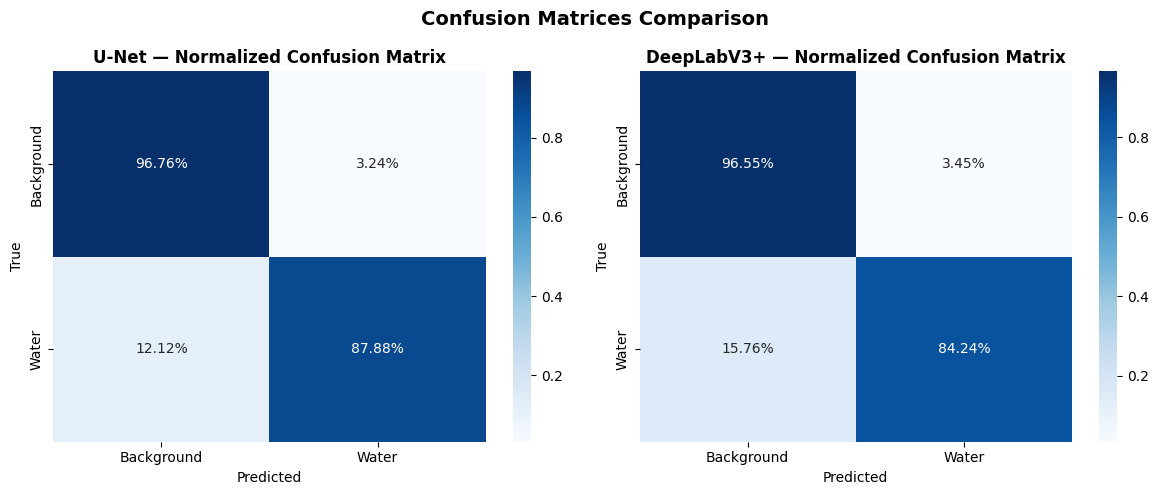

In [16]:
# ── Confusion matrices side by side ──
unet_preds_flat    = (unet_probs.flatten()    > UNET_THRESH).astype(int)
deeplab_preds_flat = (deeplab_probs.flatten() > DEEPLAB_THRESH).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(
        axes,
        [unet_preds_flat, deeplab_preds_flat],
        ['U-Net', 'DeepLabV3+']):
    cm = confusion_matrix(y_true_flat, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['Background','Water'],
                yticklabels=['Background','Water'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title} — Normalized Confusion Matrix', fontweight='bold')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **9. Final Verdict Table**

In [17]:
verdict_data = {
    'Criterion': [
        'IoU (test)',
        'F1 Score (test)',
        'Precision (test)',
        'Recall (test)',
        'Parameters',
        'Inference speed',
        'Training framework',
        'Pretrained backbone',
        'Input channels',
        'Model file size',
    ],
    'U-Net': [
        f"{unet_metrics['IoU']:.4f}",
        f"{unet_metrics['F1']:.4f}",
        f"{unet_metrics['Precision']:.4f}",
        f"{unet_metrics['Recall']:.4f}",
        f"{unet_params/1e6:.1f}M",
        f"{unet_img_ms:.1f} ms/img",
        'TensorFlow / Keras',
        '❌ None',
        '14',
        f'{unet_mb:.0f} MB',
    ],
    'DeepLabV3+': [
        f"{deeplab_metrics['IoU']:.4f}",
        f"{deeplab_metrics['F1']:.4f}",
        f"{deeplab_metrics['Precision']:.4f}",
        f"{deeplab_metrics['Recall']:.4f}",
        f"{deeplab_total/1e6:.1f}M",
        f"{deeplab_img_ms:.1f} ms/img",
        'PyTorch / SMP',
        '✅ EfficientNet-B3 (ImageNet)',
        '15 (+ AWEI)',
        f'{deeplab_mb:.0f} MB',
    ],
}

verdict_df = pd.DataFrame(verdict_data).set_index('Criterion')

print('\n' + '='*70)
print('FINAL COMPARISON TABLE')
print('='*70)
print(verdict_df.to_string())
print('='*70)

# ── Summary verdict ──
u_iou = unet_metrics['IoU']
d_iou = deeplab_metrics['IoU']
diff  = abs(d_iou - u_iou)
winner = 'DeepLabV3+' if d_iou > u_iou else 'U-Net'

print(f'''
📊 SUMMARY
──────────
Winner by IoU        : {winner} (+{diff:.4f})
Faster model         : {'U-Net' if unet_img_ms < deeplab_img_ms else 'DeepLabV3+'}
Smaller model        : {'U-Net' if unet_params < deeplab_total else 'DeepLabV3+'}

💡 RECOMMENDATION
─────────────────
→ For best accuracy        : {winner}
→ For deployment / edge    : U-Net (lighter, faster, no external backbone dependency)
→ For further improvement  : Try EfficientNet-B4/B5 backbone or add test-time augmentation
''')


FINAL COMPARISON TABLE
                                  U-Net                    DeepLabV3+
Criterion                                                            
IoU (test)                       0.7790                        0.7126
F1 Score (test)                  0.8757                        0.8322
Precision (test)                 0.8824                        0.7590
Recall (test)                    0.8692                        0.9211
Parameters                         7.8M                         11.7M
Inference speed             12.3 ms/img                   13.6 ms/img
Training framework   TensorFlow / Keras                 PyTorch / SMP
Pretrained backbone              ❌ None  ✅ EfficientNet-B3 (ImageNet)
Input channels                       14                   15 (+ AWEI)
Model file size                   94 MB                        136 MB

📊 SUMMARY
──────────
Winner by IoU        : U-Net (+0.0664)
Faster model         : U-Net
Smaller model        : U-Net

💡 RECOMMENDATION